# Abe et al. (2008): finite-beam multiple-reflection Maker fringes

This notebook validates `fitting_strategies.abe2008` against the numerical example in Fig. 4 of:

> M. Abe, I. Shoji, J. Suda, and T. Kondo, *Comprehensive analysis of multiple-reflection effects on rotational Maker-fringe experiments*, JOSA B **25**, 1616-1624 (2008).

Implemented path: Eqs. (27)-(31) for the multiply reflected fundamental field, Eqs. (32), (40)-(43) for nonlinear polarization and single-path SH fields, Eqs. (44)-(45) for SH reflections, and Eq. (46) for the output-plane power integral. Absolute angle-independent SI factors are omitted, so powers are relative but all curves share one scale.

## Scope of this first implementation

- Plane-parallel, nonabsorbing plate; dielectric axes coincide with lab x/y/z.
- One s or p eigenmode at each frequency.
- Nondiverging Gaussian field with one explicit transverse coordinate x; the y integral is analytic as in Eq. (46).
- The nonlinear source direction is supplied explicitly. For Fig. 4, s-in/p-out with only d31=d32 gives a z-directed source, $P_z^{NL}\propto E_y^2$.
- This is a simulation/reference implementation. General mixed-polarization d-tensor fitting is a later extension.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if repo_root.name == 'test_codes':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from fitting_strategies.abe2008 import (
    Abe2008FiniteBeamModel,
    sic_fig4_parameters,
)

plt.rcParams.update({'figure.figsize': (9, 5), 'axes.grid': True})

## 1. Parameters quoted for Fig. 4

The paper uses $L=400~\mu$m, $a=400~\mu$m, $\lambda_\omega=1.064~\mu$m, $n_o^\omega=2.5464$, $n_o^{2\omega}=2.6289$, and $n_e^{2\omega}=2.6716$. Here `m=1` means that terms m=0 and m=1 are retained; `m=4` retains five terms, matching the paper's convention.

In [2]:
base = sic_fig4_parameters(x_points=401, z_points=801)
base

Abe2008Parameters(wavelength_um=1.064, thickness_um=400.0, beam_radius_um=400.0, n_w_xyz=(2.5464, 2.5464, 2.5464), n_2w_xyz=(2.6289, 2.6289, 2.6716), fundamental_polarization='s', sh_polarization='p', nonlinear_source_xyz=(0.0, 0.0, 1.0), max_fundamental_round_trips=4, max_sh_round_trips=4, include_fundamental_reflections=True, include_sh_reflections=True, x_points=401, z_points=801, transverse_margin_radii=4.5)

## 2. Fig. 4-style reflection-order comparison

This is the main calculation. On a typical workstation the three 121-angle curves take roughly tens of seconds.

In [3]:
theta_deg = np.linspace(0.0, 60.0, 121)

single_params = replace(
    base,
    include_fundamental_reflections=False,
    include_sh_reflections=False,
    max_fundamental_round_trips=0,
    max_sh_round_trips=0,
)
m1_params = replace(base, max_fundamental_round_trips=1, max_sh_round_trips=1)
m4_params = replace(base, max_fundamental_round_trips=4, max_sh_round_trips=4)

started = time.perf_counter()
p_single = Abe2008FiniteBeamModel(single_params).power(theta_deg)
p_m1 = Abe2008FiniteBeamModel(m1_params).power(theta_deg)
p_m4 = Abe2008FiniteBeamModel(m4_params).power(theta_deg)
print(f'calculation time: {time.perf_counter() - started:.1f} s')

calculation time: 48.5 s


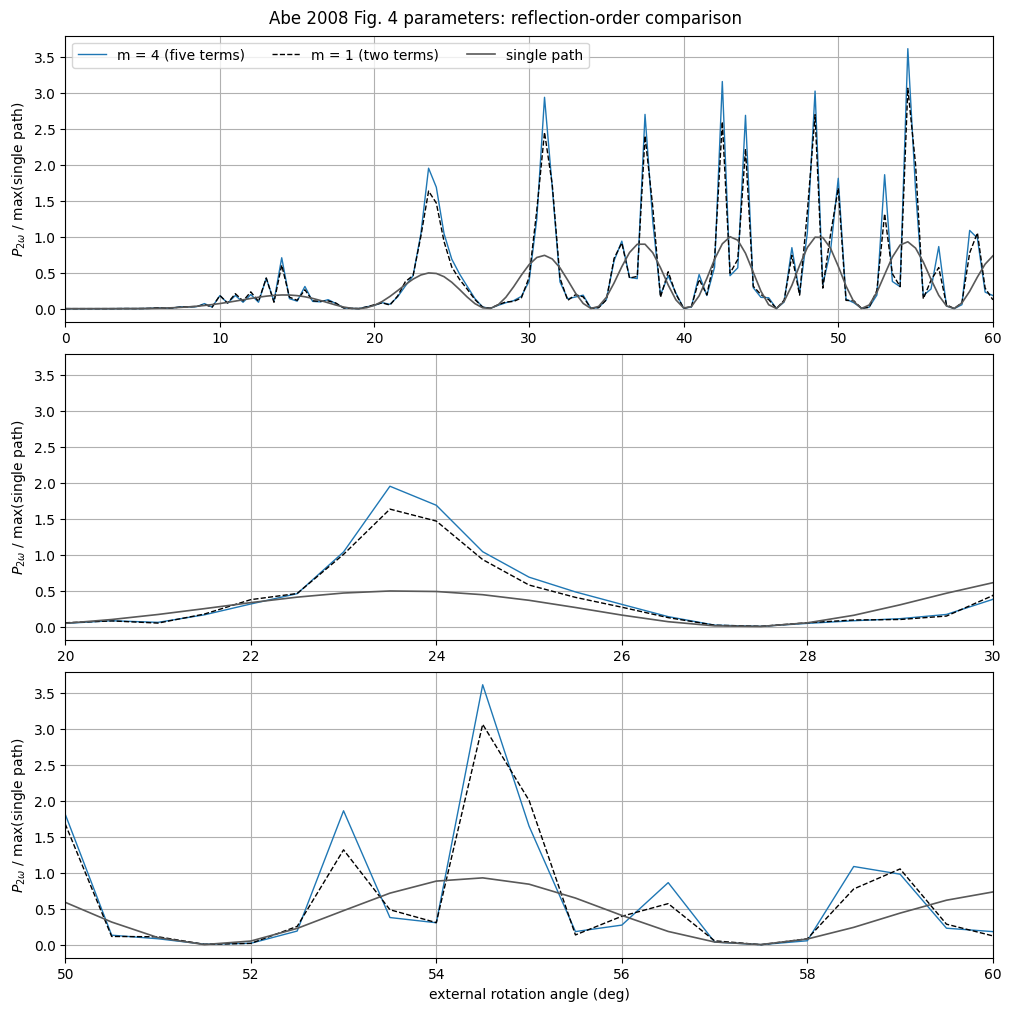

In [4]:
scale = np.max(p_single)
fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True)
for ax, xlim in zip(axes, [(0, 60), (20, 30), (50, 60)]):
    ax.plot(theta_deg, p_m4 / scale, lw=1.0, label='m = 4 (five terms)')
    ax.plot(theta_deg, p_m1 / scale, 'k--', lw=1.0, label='m = 1 (two terms)')
    ax.plot(theta_deg, p_single / scale, color='0.35', lw=1.2, label='single path')
    ax.set_xlim(*xlim)
    ax.set_ylabel(r'$P_{2\omega}$ / max(single path)')
axes[-1].set_xlabel('external rotation angle (deg)')
axes[0].legend(ncol=3)
fig.suptitle('Abe 2008 Fig. 4 parameters: reflection-order comparison')
plt.show()

The exact sampled maximum depends strongly on angular step because Fabry-Perot oscillations are narrow. The paper's 'almost fourfold' statement is best checked with a pointwise ratio away from single-path nodes, not by dividing two independently sampled global maxima.

max robust pointwise enhancement: 4.68 at 56.50 deg
global sampled peak ratio: 3.61


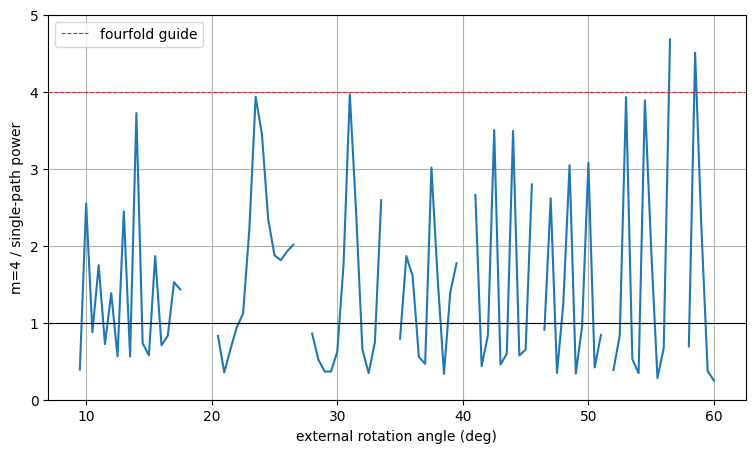

In [5]:
valid = p_single > 0.05 * np.max(p_single)
enhancement = np.full_like(p_single, np.nan)
enhancement[valid] = p_m4[valid] / p_single[valid]
best = np.nanargmax(enhancement)
print(f'max robust pointwise enhancement: {enhancement[best]:.2f} at {theta_deg[best]:.2f} deg')
print(f'global sampled peak ratio: {np.max(p_m4) / np.max(p_single):.2f}')

fig, ax = plt.subplots()
ax.plot(theta_deg, enhancement)
ax.axhline(1.0, color='k', lw=0.8)
ax.axhline(4.0, color='tab:red', ls='--', lw=0.8, label='fourfold guide')
ax.set(xlabel='external rotation angle (deg)', ylabel='m=4 / single-path power', ylim=(0, 5))
ax.legend()
plt.show()

## 3. Separate the fundamental and SH reflection effects

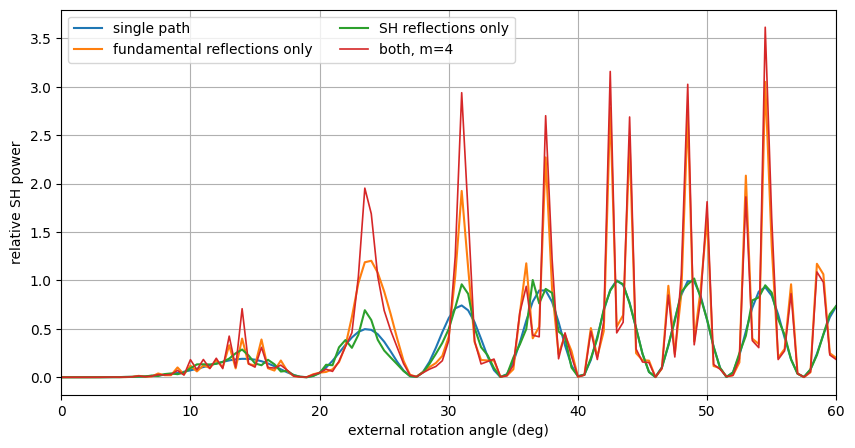

In [6]:
fundamental_only = replace(m4_params, include_sh_reflections=False)
sh_only = replace(m4_params, include_fundamental_reflections=False)
p_fundamental_only = Abe2008FiniteBeamModel(fundamental_only).power(theta_deg)
p_sh_only = Abe2008FiniteBeamModel(sh_only).power(theta_deg)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(theta_deg, p_single / scale, label='single path')
ax.plot(theta_deg, p_fundamental_only / scale, label='fundamental reflections only')
ax.plot(theta_deg, p_sh_only / scale, label='SH reflections only')
ax.plot(theta_deg, p_m4 / scale, label='both, m=4', lw=1.2)
ax.set(xlabel='external rotation angle (deg)', ylabel='relative SH power', xlim=(0, 60))
ax.legend(ncol=2)
plt.show()

## 4. Numerical convergence

The z integral contains the Maker-fringe phase. Simpson integration converges much faster than a simple trapezoidal rule, but it should still be checked before quantitative fitting.

In [7]:
probe_angles = np.array([20.0, 30.0, 54.0])
z_counts = [401, 601, 801, 1201, 1601]
convergence = {}
for nz in z_counts:
    params = replace(m4_params, x_points=401, z_points=nz)
    convergence[nz] = Abe2008FiniteBeamModel(params).power(probe_angles)

reference = convergence[z_counts[-1]]
for nz in z_counts:
    rel = np.abs(convergence[nz] / reference - 1.0)
    print(f'z_points={nz:4d}: power={convergence[nz]}, relative error={rel}')

assert np.allclose(convergence[801], reference, rtol=0.01), 'Increase z_points for these parameters.'

z_points= 401: power=[ 3.84119374 32.09754078 25.9075783 ], relative error=[0.01212768 0.01320009 0.01715932]
z_points= 601: power=[ 3.80349641 31.75480191 25.5485023 ], relative error=[0.00219469 0.00238109 0.00306161]
z_points= 801: power=[ 3.79762967 31.7016492  25.4934765 ], relative error=[0.00064885 0.00070326 0.00090124]
z_points=1201: power=[ 3.79551641 31.68252793 25.47376781], relative error=[9.20200040e-05 9.96724147e-05 1.27457198e-04]
z_points=1601: power=[ 3.79516718 31.67937037 25.47052141], relative error=[0. 0. 0.]


The paper states that paths through about five round trips remain significant and checks the sum through m=10. The same reflection-order check is made here at three representative angles.

In [8]:
order_convergence = {}
for max_m in [1, 4, 6, 8, 10]:
    params = replace(
        base,
        max_fundamental_round_trips=max_m,
        max_sh_round_trips=max_m,
    )
    order_convergence[max_m] = Abe2008FiniteBeamModel(params).power(probe_angles)
    print(f'm={max_m:2d}: {order_convergence[max_m]}')

assert np.allclose(order_convergence[4], order_convergence[10], rtol=0.01)

m= 1: [ 4.56770138 36.11926811 25.63486991]
m= 4: [ 3.79762967 31.7016492  25.4934765 ]
m= 6: [ 3.79808002 31.69183333 25.51980763]
m= 8: [ 3.79802664 31.69325311 25.5199547 ]
m=10: [ 3.79794304 31.69265692 25.51993664]


## 5. Output-plane partial overlap

The following plot exposes what an intensity-only correction cannot retain: displaced complex SH fields overlap only over part of the beam.

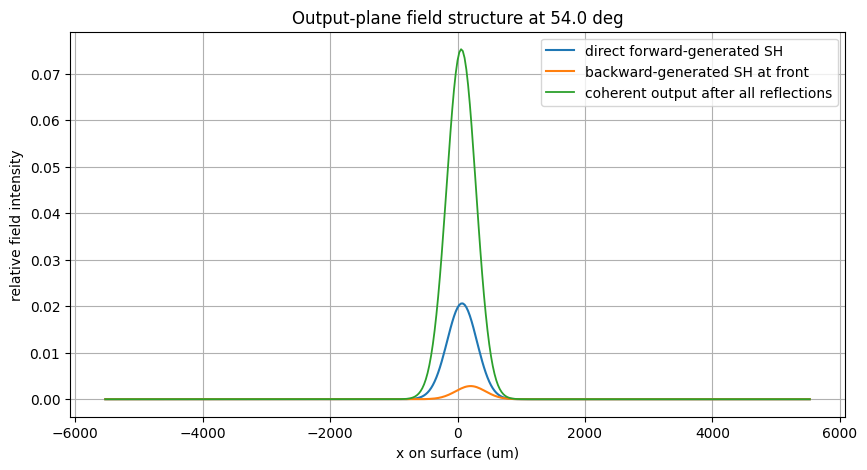

fundamental Poynting slope dx/dz = 0.3351
SH Poynting slope dx/dz = 0.3127
fundamental internal reflection amplitude = 0.6084+0.0000j
SH internal reflection amplitude = -0.2370+0.0000j


In [9]:
angle_to_inspect = 54.0
result = Abe2008FiniteBeamModel(m4_params).calculate_angle(angle_to_inspect)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result.x_um, np.abs(result.e_plus_single_path)**2, label='direct forward-generated SH')
ax.plot(result.x_um, np.abs(result.e_minus_single_path)**2, label='backward-generated SH at front')
ax.plot(result.x_um, np.abs(result.e_out)**2, label='coherent output after all reflections', lw=1.3)
ax.set(
    xlabel='x on surface (um)',
    ylabel='relative field intensity',
    title=f'Output-plane field structure at {angle_to_inspect:.1f} deg',
)
ax.legend()
plt.show()

print(f'fundamental Poynting slope dx/dz = {result.fundamental_slope:.4f}')
print(f'SH Poynting slope dx/dz = {result.sh_slope:.4f}')
print(f'fundamental internal reflection amplitude = {result.r_w:.4f}')
print(f'SH internal reflection amplitude = {result.r_2w:.4f}')

## Interpretation and next step

Successful checks are: finite nonnegative power, clear order-unity deviation from the single-path result, convergence with reflection order and quadrature, and a pointwise enhancement approaching the roughly fourfold scale reported in the paper. Exact digitization-level agreement with Fig. 4 is not claimed yet because the paper does not state every normalization and numerical-grid detail.

The next implementation step is to connect the existing crystal-axis transforms and full 3x6 d tensor from `Braun1997Strategy`, allowing mixed input polarization and direct fitting of BaMgF4 measurements.